In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importing DATASET

DATA PREPROCESSING

In [67]:
df = pd.read_csv('/content/zomato.csv')
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [68]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [69]:
df = df.drop(['url', 'address', 'phone', 'dish_liked', 'reviews_list', 'menu_item', 'listed_in(city)'], axis=1, errors='ignore')
df = df.rename(columns={'approx_cost(for two people)': 'Cost', 'listed_in(type)': 'type'})

In [70]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
       'rest_type', 'cuisines', 'Cost', 'type'],
      dtype='object')

In [71]:
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,Cost,type
0,Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet
4,Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Buffet


In [72]:
df.shape

(51717, 10)

In [73]:
df.dtypes

,0
name,object
online_order,object
book_table,object
rate,object
votes,int64
location,object
rest_type,object
cuisines,object
Cost,object
type,object


In [74]:
df['rate'] = pd.to_numeric(df['rate'].astype(str).str.split('/').str[0].str.strip(), errors='coerce')

In [75]:
df['Cost'] = pd.to_numeric(df['Cost'].astype(str).str.replace(',', ''), errors='coerce')

In [76]:
df.isna().sum()

,0
name,0
online_order,0
book_table,0
rate,10052
votes,0
location,21
rest_type,227
cuisines,45
Cost,346
type,0


In [77]:
df = df.dropna(subset = ['rate'])

In [78]:
df['rest_type'] = df['rest_type'].fillna(df['rest_type'].mode()[0])
df['cuisines'] = df['cuisines'].fillna(df['cuisines'].mode()[0])

In [79]:
df['Cost']= df['Cost'].fillna(df['Cost'].median())

In [80]:
df.isnull().sum()

,0
name,0
online_order,0
book_table,0
rate,0
votes,0
location,0
rest_type,0
cuisines,0
Cost,0
type,0


In [81]:
for col in ['Cost','rate']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: detected", len(outliers), "outliers; bounds:", lower, upper)

Cost: detected 3150 outliers; bounds: -300.0 1300.0
rate: detected 187 outliers; bounds: 2.5 4.9


In [82]:
outliers[['Cost']].head(10)

,Cost
1532,450.0
1570,750.0
1573,500.0
1637,500.0
1647,250.0
2028,750.0
2030,500.0
2044,500.0
2048,250.0
2121,750.0


In [83]:
outliers[['rate']].head()

,rate
1532,2.4
1570,2.2
1573,2.4
1637,2.4
1647,2.3


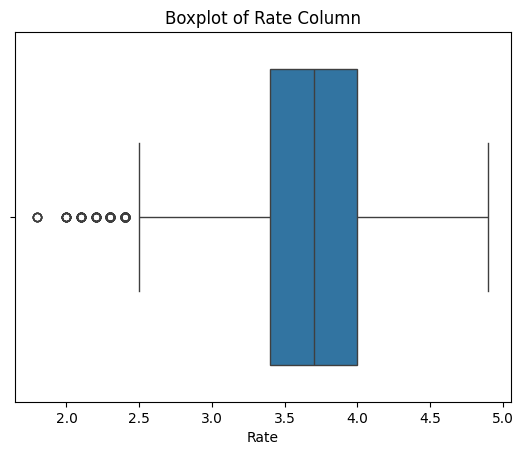

In [84]:
sns.boxplot(x=df['rate'])
plt.title('Boxplot of Rate Column')
plt.xlabel('Rate')
plt.show()

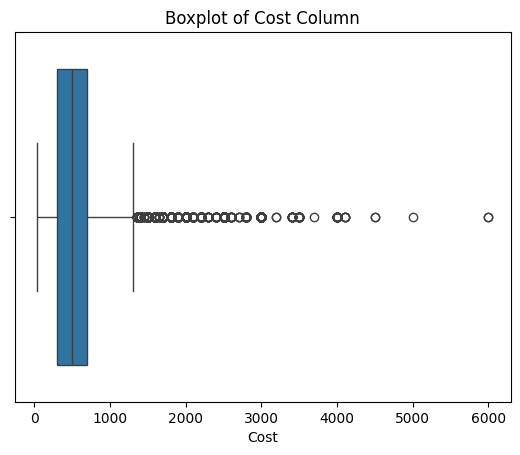

In [85]:
sns.boxplot(x=df['Cost'])
plt.title('Boxplot of Cost Column')
plt.xlabel('Cost')
plt.show()

In [86]:
q_upper = df['Cost'].quantile(0.95)
df['Cost'] = np.where(df['Cost'] > q_upper, q_upper, df['Cost'])

# Model Training

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
X = df[['Cost']]
y = df['rate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [88]:
y_pred = lr.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R2 Score (Variance explained): {r2:.4f}")

Mean Squared Error: 0.1640
R2 Score (Variance explained): 0.1524


Descision tree Training Model

In [89]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

features = ['Cost', 'votes', 'online_order', 'book_table']
target = 'rate'

df_clean = df.dropna(subset=features + [target])

X = df_clean[features]
y = df_clean[target]

X = pd.get_dummies(X, columns=['online_order', 'book_table'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R2 Score (Variance explained): {r2:.4f}")

Mean Squared Error: 0.0870
R2 Score (Variance explained): 0.5505


### Actual vs. Predicted Values: Linear Regression Model

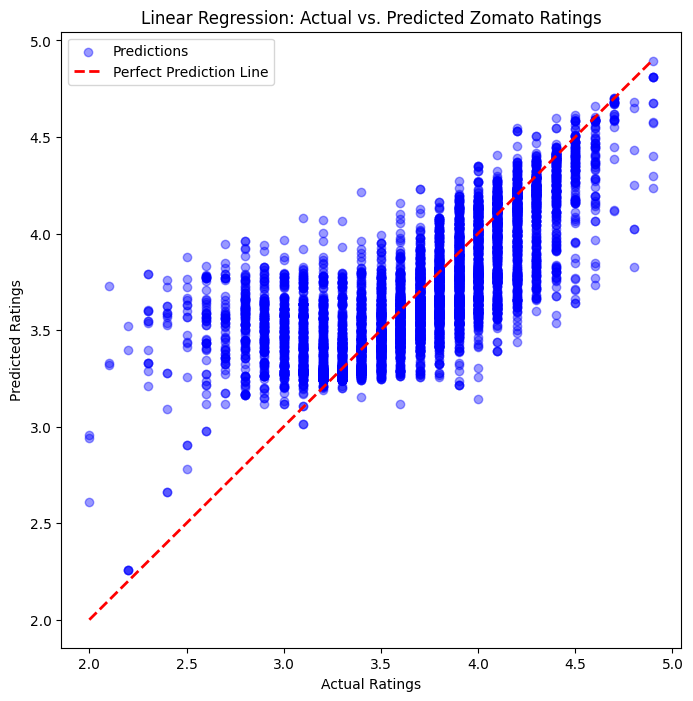

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.scatter(y_test, y_pred, alpha=0.4, color='blue', label='Predictions')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')

plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.title('Linear Regression: Actual vs. Predicted Zomato Ratings')
plt.legend()
plt.show()

### Actual vs. Predicted Values: Random Forest Regressor Model

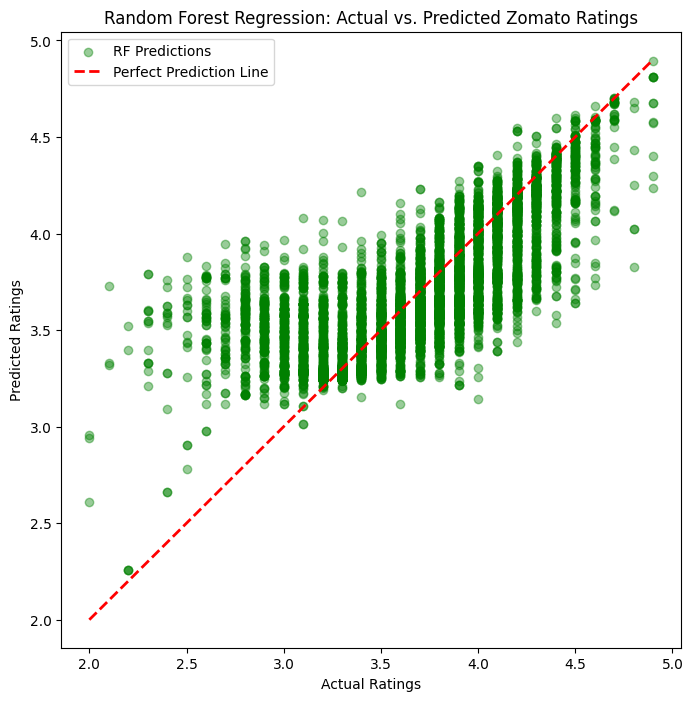

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.scatter(y_test, y_pred_rf, alpha=0.4, color='green', label='RF Predictions')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')

plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.title('Random Forest Regression: Actual vs. Predicted Zomato Ratings')
plt.legend()
plt.show()